# Set up directories

In [ ]:
# This mounts your Google Drive to the Colab VM.
from google.colab import drive
drive.mount('/content/drive')

# After confirming the location of the path, assign it to
# `FOLDERPATH` variable
FOLDERPATH = '/content/drive/MyDrive/labs/lab_2_2024_2025/'
assert FOLDERPATH is not None, "[!] Enter the foldername."

# Now that we've mounted your Drive, this ensures that
# the Python interpreter of the Colab VM can load
# python files from within it.
import sys
sys.path.insert(1, FOLDERPATH)

# Having the dataset, let's change directory to
# Lab2 folder again to continue with the exercise
%cd {FOLDERPATH}

Mounted at /content/drive
/content/drive/MyDrive/labs/lab_2_2024_2025


# Introduction to PyTorch


 We're going to leave behind your beautiful codebase and instead migrate to the most popular deep learning frameworks: [PyTorch](https://pytorch.org/)!

## Why do we use deep learning frameworks?

* Our code will now **run on GPUs**! This will allow our models to train much faster. When using a framework like PyTorch, Tensorflow or JAX you can harness the power of the GPU for your own custom neural network architectures without having to write CUDA code directly.

## What is PyTorch?

PyTorch is a system for executing **dynamic computational graphs** over Tensor objects that behave similarly as numpy ndarray.

It comes with a powerful **automatic differentiation engine** that removes the need for manual back-propagation.

## How do I learn PyTorch?

You can find the detailed [API doc](http://pytorch.org/docs/stable/index.html) here.

If you have other questions that are not addressed by the API docs, the [PyTorch forum](https://discuss.pytorch.org/) is a much better place to ask than StackOverflow.

# Table of Contents

This Project has four parts. We will do PyTorch on **three different levels of abstraction**, which will help us understand it better 

1. Part I, Preparation: we will use CIFAR-10 dataset.
2. Part II, **Barebones PyTorch**: *Abstraction level 1*, we will work directly with the lowest-level PyTorch Tensors.
3. Part III, **PyTorch Module API**: *Abstraction level 2*, we will use `nn.Module` to define arbitrary neural network architecture.
4. Part IV, **PyTorch Sequential API**: *Abstraction level 3*, we will use `nn.Sequential` to define a linear feed-forward network very conveniently.

Here is a table of comparison:

| API           | Flexibility | Convenience |
|---------------|-------------|-------------|
| Barebone      | High        | Low         |
| `nn.Module`     | High        | Medium      |
| `nn.Sequential` | Low         | High        |

# GPU

We can manually switch to a GPU device on Colab by clicking `Runtime -> Change runtime type` and selecting `GPU` under `Hardware Accelerator`.

## Setup

We should switch to GPU before running the following cells to import packages, since the kernel gets restarted upon switching runtimes.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.utils.data import sampler

import torchvision.datasets as datasets
import torchvision.transforms as T

import numpy as np

USE_GPU = True
dtype = torch.float32 # We will be using float throughout this tutorial.

if USE_GPU and torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

# Constant to control how frequently we print train loss.
print_every = 100
print('using device:', device)

using device: cuda


# Part I. Preparation

## Load CIFAR-10 dataset

Now, let's load the CIFAR-10 dataset.

This might take a couple minutes the first time you do it, but the files should stay cached after that.

To make the whole procedure more efficient, we managed to save the whole dataset in ``.npy`` files.

PyTorch provides some convenient tools to automate this process even more for us.

In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

# Define the mean and standard deviation for CIFAR-10
mean = (0.4914, 0.4822, 0.4465)  # Precomputed mean for CIFAR-10
std = (0.2023, 0.1994, 0.2010)   # Precomputed std for CIFAR-10

# Define the transform for preprocessing and data augmentation
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# Load the CIFAR-10 dataset
dataset_path = '/content/drive/MyDrive/labs/'  # Replace with your dataset path
cifar10_dataset = datasets.CIFAR10(root=dataset_path, train=True, download=False, transform=transform) # Use download=True in case you do not have already downloaded

# Split the dataset into train, val, and test sets
num_train = 45000  # Number of training examples
num_val = 5000    # Number of validation examples
num_test = 10000   # Number of test examples (CIFAR-10 test set size)

train_dataset, val_dataset = random_split(cifar10_dataset, [num_train, num_val])

test_dataset = datasets.CIFAR10(root=dataset_path, train=False, download=True, transform=transform)

# Define DataLoaders
batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Print dataset sizes for verification
print(f"Train set size: {len(train_dataset)}")
print(f"Validation set size: {len(val_dataset)}")
print(f"Test set size: {len(test_dataset)}")

Files already downloaded and verified
Train set size: 45000
Validation set size: 5000
Test set size: 10000


## Visualize the class distributions

We have now defined our train, validation and test dataloaders. However, it would be good to check the data distribution of each dataloader, in order to check how many examples per class are included. We do this as a sanity check, as we want our dataloaders to be distributed close to uniform. Let's define some helper functions:

In [ ]:
import numpy as np
from collections import Counter

def get_class_distribution(loader, dataset_classes):
    """
    Computes the distribution of classes in a DataLoader.

    Args:
    - loader: DataLoader to inspect
    - dataset_classes: List of class names for the dataset

    Returns:
    - class_counts: Dictionary with class names as keys and counts as values
    """
    class_counts = Counter()
    for inputs, labels in loader:
        class_counts.update(labels.numpy())

    # Convert to a dictionary with class names
    class_distribution = {dataset_classes[i]: class_counts[i] for i in range(len(dataset_classes))}
    return class_distribution

def display_class_distribution(distribution, title="Class Distribution"):
    """
    Displays the class distribution as a bar chart.

    Args:
    - distribution: Dictionary with class names as keys and counts as values
    - title: Title for the bar chart
    """
    import matplotlib.pyplot as plt

    class_names = list(distribution.keys())
    counts = list(distribution.values())

    plt.figure(figsize=(10, 6))
    plt.bar(class_names, counts)
    plt.title(title)
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()

Now, let's visualize the distribution of the examples per class for each dataloader:

Train DataLoader Distribution:
  airplane: 4516
  automobile: 4512
  bird: 4533
  cat: 4504
  deer: 4515
  dog: 4489
  frog: 4468
  horse: 4474
  ship: 4480
  truck: 4509


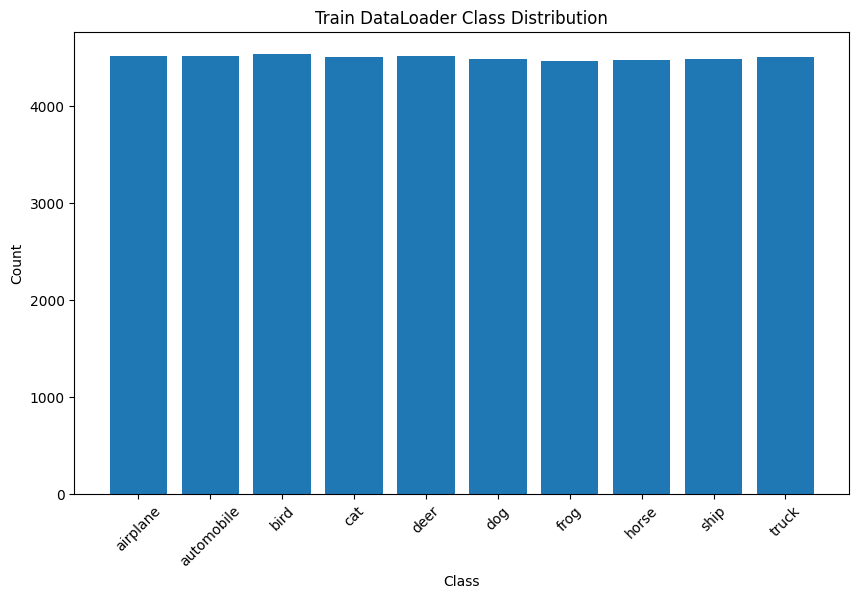

Validation DataLoader Distribution:
  airplane: 484
  automobile: 488
  bird: 467
  cat: 496
  deer: 485
  dog: 511
  frog: 532
  horse: 526
  ship: 520
  truck: 491


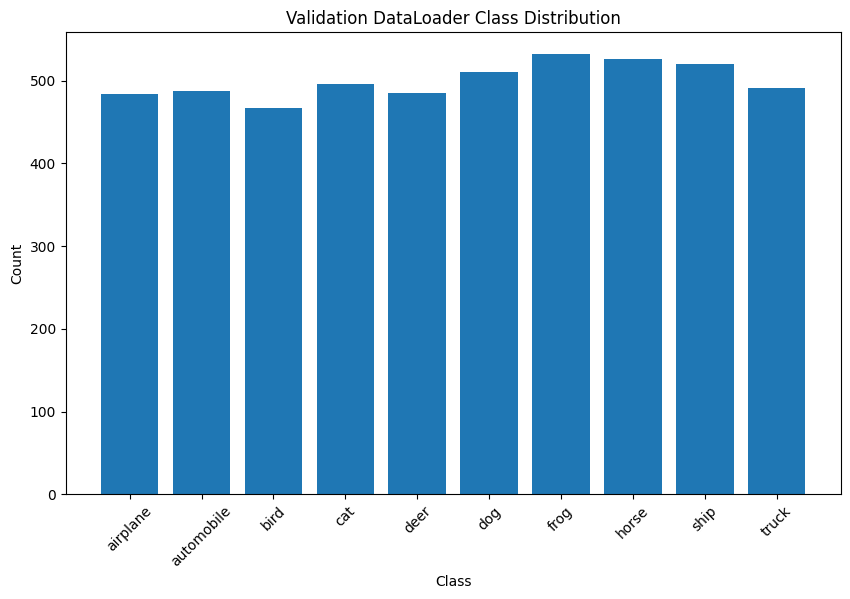

Test DataLoader Distribution:
  airplane: 1000
  automobile: 1000
  bird: 1000
  cat: 1000
  deer: 1000
  dog: 1000
  frog: 1000
  horse: 1000
  ship: 1000
  truck: 1000


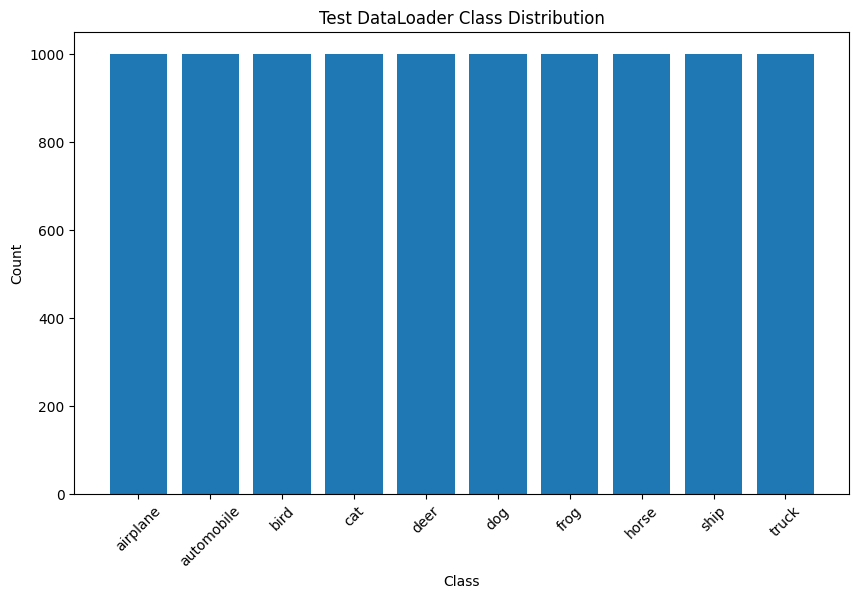

In [ ]:
# CIFAR-10 classes
cifar10_classes = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                   'dog', 'frog', 'horse', 'ship', 'truck']

# Compute and display class distribution for each DataLoader
for loader, name in [(train_loader, "Train"), (val_loader, "Validation"), (test_loader, "Test")]:
    distribution = get_class_distribution(loader, cifar10_classes)
    print(f"{name} DataLoader Distribution:")
    for cls, count in distribution.items():
        print(f"  {cls}: {count}")
    display_class_distribution(distribution, title=f"{name} DataLoader Class Distribution")

## Visualize CIFAR-10 images

Now let's visualize a few examples from each class in the CIFAR-10 dataset.

By displaying images alongside their corresponding class labels, we can verify the dataset’s contents and ensure the classes are represented correctly.

This visualization helps us understand the data distribution and provides insights into the dataset’s characteristics.

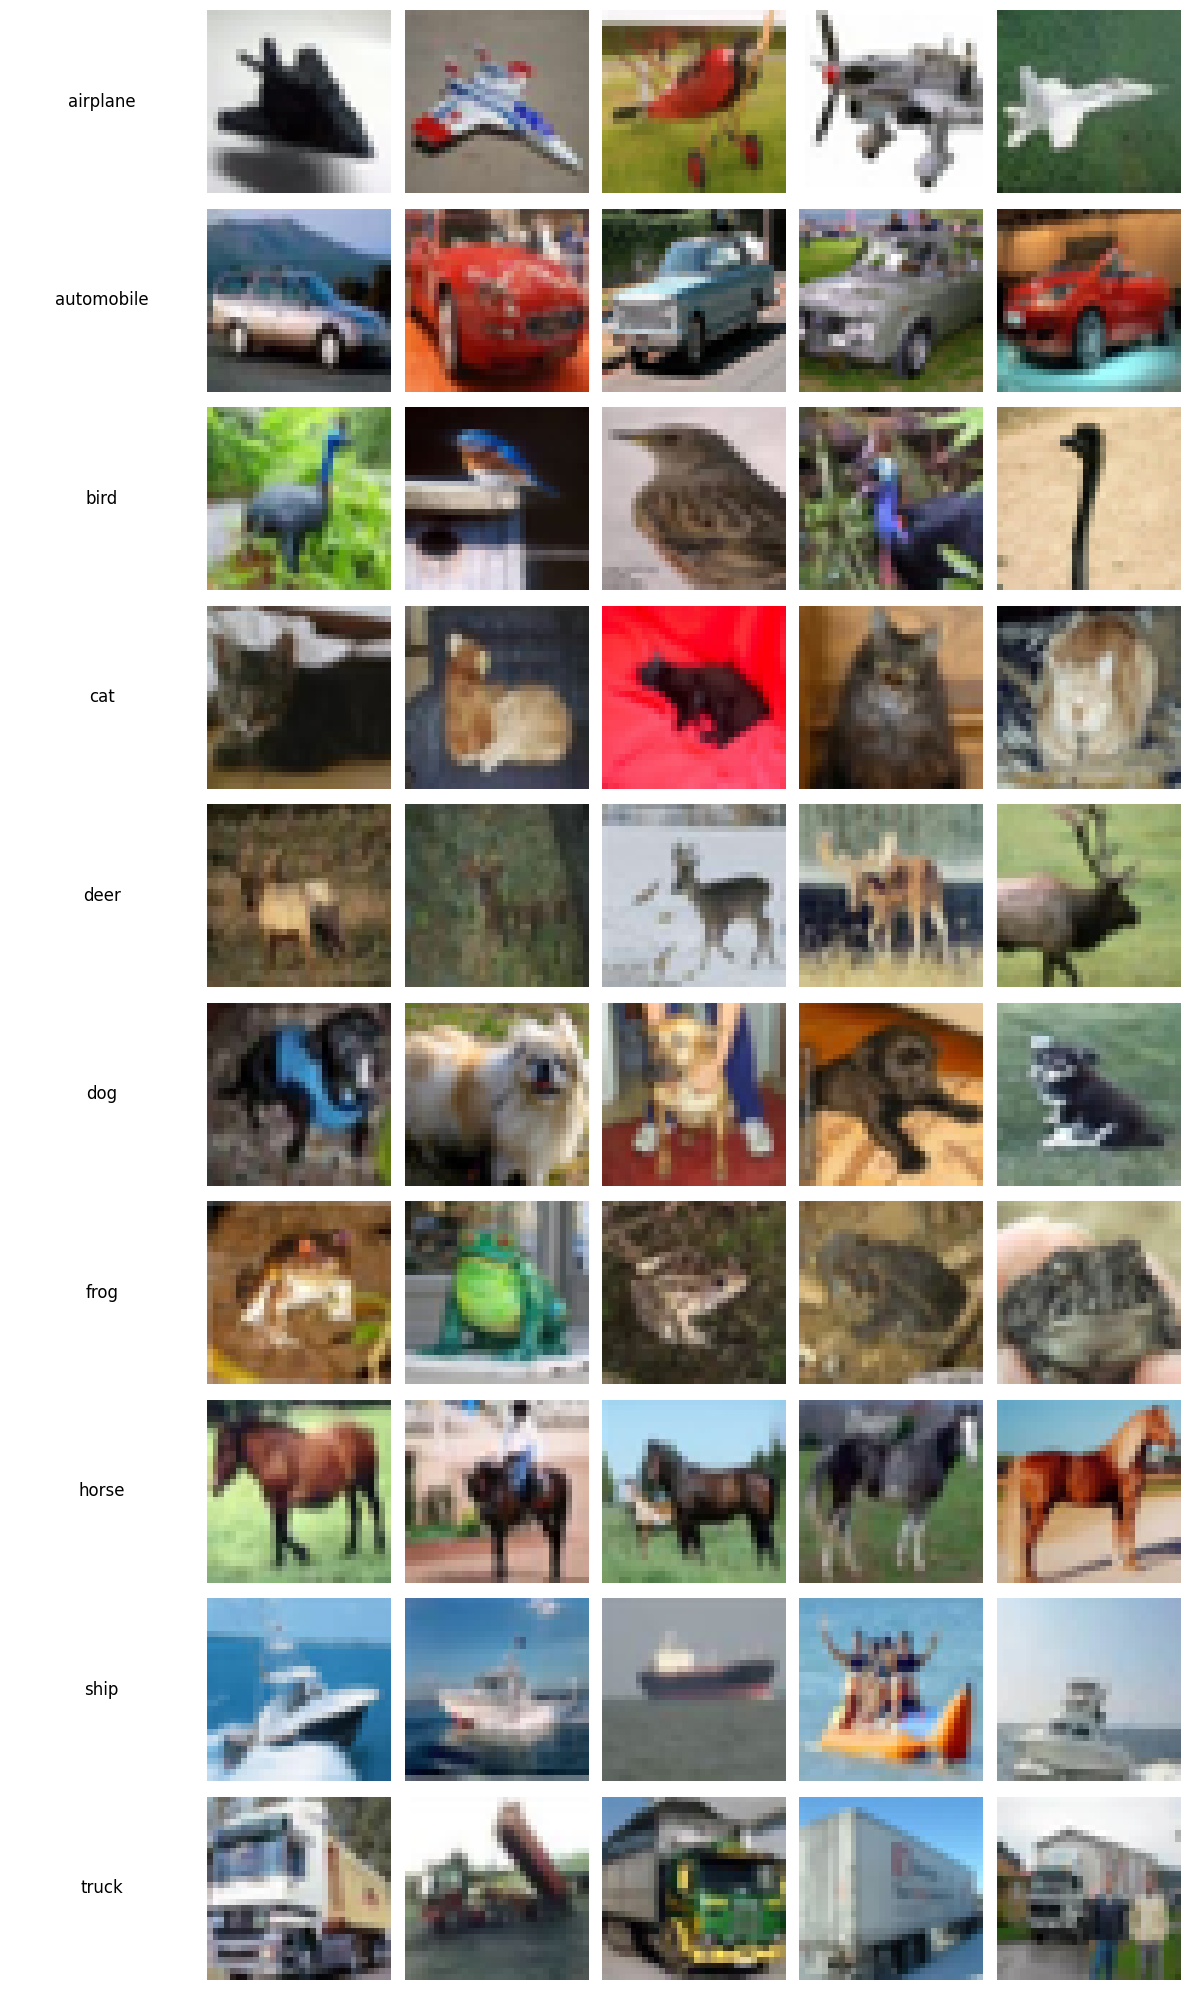

In [ ]:
import matplotlib.pyplot as plt

def visualize_images_per_class(dataset, dataset_classes, num_images=5):
    """
    Visualizes a few images from each class in the dataset.

    Args:
    - dataset: The dataset to sample from.
    - dataset_classes: List of class names for the dataset.
    - num_images: Number of images to display per class.
    """
    class_to_indices = {cls: [] for cls in range(len(dataset_classes))}

    # Group indices by class
    for idx, (_, label) in enumerate(dataset):
        if len(class_to_indices[label]) < num_images:
            class_to_indices[label].append(idx)
        if all(len(indices) == num_images for indices in class_to_indices.values()):
            break

    # Plot the images
    fig, axes = plt.subplots(len(dataset_classes), num_images + 1, figsize=((num_images + 1) * 2, len(dataset_classes) * 2))
    for cls_idx, cls_name in enumerate(dataset_classes):
        indices = class_to_indices[cls_idx]

        # Add class name to the first column of each row
        axes[cls_idx, 0].text(0.5, 0.5, cls_name, fontsize=12, ha='center', va='center', transform=axes[cls_idx, 0].transAxes)
        axes[cls_idx, 0].axis("off")

        for img_idx, data_idx in enumerate(indices):
            img, label = dataset[data_idx]
            ax = axes[cls_idx, img_idx + 1]  # Shift by 1 for the class name column
            img = img.permute(1, 2, 0)  # Convert CHW to HWC
            img = img * torch.tensor(std).view(1, 1, 3) + torch.tensor(mean).view(1, 1, 3)  # De-normalize
            img = torch.clamp(img, 0, 1)  # Clip values to valid range
            ax.imshow(img)
            ax.axis("off")
    plt.tight_layout()
    plt.show()

# Visualize 5 images per class for CIFAR-10 train set
visualize_images_per_class(cifar10_dataset, cifar10_classes, num_images=5)

# Part II. Two-Layer Network with Barebone PyTorch

PyTorch comes with high-level APIs to help us define model architectures conveniently, which we will cover in Part II. In this section, we will start with the **barebone** PyTorch elements to understand the autograd engine better. 

We will start with a simple fully-connected ReLU network with two hidden layers and no biases for CIFAR-10 classification.

This implementation computes the **forward** pass using operations on PyTorch Tensors, and uses PyTorch `autograd` to compute gradients. 

When we create a PyTorch Tensor with `requires_grad=True`, then operations involving that Tensor will not just compute values; they will also build up a **computational graph** in the background, allowing us to easily backpropagate through the graph to compute gradients of some Tensors with respect to a downstream loss. Concretely if x is a Tensor with `x.requires_grad == True` then after backpropagation `x.grad` will be another Tensor holding the gradient of x with respect to the scalar loss at the end.

## PyTorch Tensors: Flatten Function
A PyTorch Tensor is conceptionally similar to a numpy array: it is an n-dimensional grid of numbers and, like numpy, PyTorch provides many functions to efficiently operate on Tensors. As a simple example, we provide a `flatten` function below which reshapes image data for use in a fully-connected neural network.

Recall that image data is typically stored in a Tensor of shape `N x C x H x W`, where:

* `N` is the number of datapoints
* `C` is the number of channels
* `H` is the height of the intermediate feature map in pixels
* `W` is the height of the intermediate feature map in pixels

This is the right way to represent the data when we are doing something like a 2D convolution, that needs **spatial understanding** of where the intermediate features are relative to each other. When we use fully connected affine layers to process the image, however, we want each datapoint to be represented by a **single vector** - it's no longer useful to segregate the different channels, rows, and columns of the data. So, we use a "flatten" operation to collapse the `C x H x W` values per representation into a single long vector. The flatten function below first reads in the N, C, H, and W values from a given batch of data, and then returns a "view" of that data. "View" is analogous to numpy's "reshape" method: it reshapes x's dimensions to be N x ??, where ?? is allowed to be anything (in this case, it will be `C x H x W`, but we don't need to specify that explicitly).

In [ ]:
def flatten(x):
    N = x.shape[0] # read in N, C, H, W
    return x.view(N, -1)  # "flatten" the C * H * W values into a single vector per image

def test_flatten():
    x = torch.arange(12).view(2, 1, 3, 2)
    print('Before flattening: ', x)
    print('After flattening: ', flatten(x))

test_flatten()

Before flattening:  tensor([[[[ 0,  1],
          [ 2,  3],
          [ 4,  5]]],


        [[[ 6,  7],
          [ 8,  9],
          [10, 11]]]])
After flattening:  tensor([[ 0,  1,  2,  3,  4,  5],
        [ 6,  7,  8,  9, 10, 11]])


## Barebone PyTorch: Two-Layer Network

Here we define a function `two_layer_fc` which performs the **forward** pass of a two-layer fully-connected ReLU network on a batch of image data. After defining the forward pass we check that it doesn't crash and that it produces outputs of the right shape by running zeros through the network.

In [ ]:
import torch.nn.functional as F  # useful stateless functions

def two_layer_fc(x, params):
    """
    A fully-connected neural networks; the architecture is:
    NN is fully connected -> ReLU -> fully connected layer.
    Note that this function only defines the forward pass;
    PyTorch will take care of the backward pass for us.

    The input to the network will be a minibatch of data, of shape
    (N, d1, ..., dM) where d1 * ... * dM = D. The hidden layer will have H units,
    and the output layer will produce scores for C classes.

    Inputs:
    - x: A PyTorch Tensor of shape (N, d1, ..., dM) giving a minibatch of
      input data.
    - params: A list [w1, w2] of PyTorch Tensors giving weights for the network;
      w1 has shape (D, H) and w2 has shape (H, C).

    Returns:
    - scores: A PyTorch Tensor of shape (N, C) giving classification scores for
      the input data x.
    """
    # first we flatten the image
    x = flatten(x)  # shape: [batch_size, C x H x W]

    w1, w2 = params

    # Forward pass: compute predicted y using operations on Tensors. Since w1 and
    # w2 have requires_grad=True, operations involving these Tensors will cause
    # PyTorch to build a computational graph, allowing automatic computation of
    # gradients. Since we are no longer implementing the backward pass by hand we
    # don't need to keep references to intermediate values.
    # you can also use `.clamp(min=0)`, equivalent to F.relu()
    x = F.relu(x.mm(w1))
    x = x.mm(w2)
    return x


def two_layer_fc_test():
    hidden_layer_size = 42
    x = torch.zeros((64, 50), dtype=dtype)  # minibatch size 64, feature dimension 50
    w1 = torch.zeros((50, hidden_layer_size), dtype=dtype)
    w2 = torch.zeros((hidden_layer_size, 10), dtype=dtype)
    scores = two_layer_fc(x, [w1, w2])
    print(scores.size())  # you should see [64, 10]

two_layer_fc_test()

torch.Size([64, 10])


## Barebone PyTorch: Initialization
Let's write a couple utility methods to initialize the weight matrices for our models.

- `random_weight(shape)` initializes a weight tensor with the Kaiming normalization method.
- `zero_weight(shape)` initializes a weight tensor with all zeros. Useful for instantiating bias parameters.

The `random_weight` function uses the Kaiming normal initialization method, described in:

He et al, *Delving Deep into Rectifiers: Surpassing Human-Level Performance on ImageNet Classification*, ICCV 2015, https://arxiv.org/abs/1502.01852

In [ ]:
def random_weight(shape):
    """
    Create random Tensors for weights; setting requires_grad=True means that we
    want to compute gradients for these Tensors during the backward pass.
    We use Kaiming normalization: sqrt(2 / fan_in)
    """
    if len(shape) == 2:  # FC weight
        fan_in = shape[0]
    else:
        fan_in = np.prod(shape[1:]) # conv weight [out_channel, in_channel, kH, kW]
    # randn is standard normal distribution generator.
    w = torch.randn(shape, device=device, dtype=dtype) * np.sqrt(2. / fan_in)
    w.requires_grad = True
    return w

def zero_weight(shape):
    return torch.zeros(shape, device=device, dtype=dtype, requires_grad=True)

# create a weight of shape [3 x 5]
# you should see the type `torch.cuda.FloatTensor` if you use GPU.
# Otherwise it should be `torch.FloatTensor`
random_weight((3, 5))

tensor([[-1.4933,  0.1690, -1.3071, -0.4461,  1.3387],
        [-0.3280,  1.3664,  0.3794,  1.1557, -0.0627],
        [ 0.2057,  0.5542,  0.2424, -0.6722,  0.9478]], device='cuda:0',
       requires_grad=True)

## Barebone PyTorch: Check Accuracy
When training the model we will use the following function to check the accuracy of our model on the training or validation set.

When checking accuracy we don't need to compute any gradients; as a result we don't need PyTorch to build a computational graph for us when we compute scores. To prevent a graph from being built we scope our computation under a `torch.no_grad()` context manager.

In [ ]:
def check_accuracy_part2(loader, model_fn, params):
    """
    Check the accuracy of a classification model.

    Inputs:
    - loader: A DataLoader for the data split we want to check
    - model_fn: A function that performs the forward pass of the model,
      with the signature scores = model_fn(x, params)
    - params: List of PyTorch Tensors giving parameters of the model

    Returns: Nothing, but prints the accuracy of the model
    """
    #split = 'val' if loader.dataset.train else 'test'
    split = 'val' if len(loader) == 79 else 'test'
    print('Checking accuracy on the %s set' % split)
    num_correct, num_samples = 0, 0
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device=device, dtype=dtype)  # move to device, e.g. GPU
            y = y.to(device=device, dtype=torch.int64)
            scores = model_fn(x, params)
            _, preds = scores.max(1)
            num_correct += (preds == y).sum()
            num_samples += preds.size(0)
        acc = float(num_correct) / num_samples
        print('Got %d / %d correct (%.2f%%)' % (num_correct, num_samples, 100 * acc))

## BareBone PyTorch: Training Loop
We can now set up a basic training loop to train our network. We will train the model using stochastic gradient descent without momentum. We will use `torch.functional.cross_entropy` to compute the loss; you can [read about it here](http://pytorch.org/docs/stable/nn.html#cross-entropy).

The training loop takes as input the neural network function, a list of initialized parameters (`[w1, w2]` in our example), and learning rate.

In [ ]:
def train_part2(model_fn, params, learning_rate):
    """
    Train a model on CIFAR-10.

    Inputs:
    - model_fn: A Python function that performs the forward pass of the model.
      It should have the signature scores = model_fn(x, params) where x is a
      PyTorch Tensor of image data, params is a list of PyTorch Tensors giving
      model weights, and scores is a PyTorch Tensor of shape (N, C) giving
      scores for the elements in x.
    - params: List of PyTorch Tensors giving weights for the model
    - learning_rate: Python scalar giving the learning rate to use for SGD

    Returns: Nothing
    """
    for t, (x, y) in enumerate(train_loader):
        # Move the data to the proper device (GPU or CPU)
        x = x.to(device=device, dtype=dtype)
        y = y.to(device=device, dtype=torch.long)

        # Forward pass: compute scores and loss
        scores = model_fn(x, params)
        loss = F.cross_entropy(scores, y)

        # Backward pass: PyTorch figures out which Tensors in the computational
        # graph has requires_grad=True and uses backpropagation to compute the
        # gradient of the loss with respect to these Tensors, and stores the
        # gradients in the .grad attribute of each Tensor.
        loss.backward()

        # Update parameters. We don't want to backpropagate through the
        # parameter updates, so we scope the updates under a torch.no_grad()
        # context manager to prevent a computational graph from being built.
        with torch.no_grad():
            for w in params:
                w -= learning_rate * w.grad

                # Manually zero the gradients after running the backward pass
                w.grad.zero_()

        if t % print_every == 0:
            print('Iteration %d, loss = %.4f' % (t, loss.item()))
            check_accuracy_part2(val_loader, model_fn, params)
            print()

## BareBones PyTorch: Train a Two-Layer Network
Now we are ready to run the training loop. We need to explicitly allocate tensors for the fully connected weights, `w1` and `w2`.

Each minibatch of CIFAR-10 has 64 examples, so the tensor shape is `[64, 3, 32, 32]`.

After flattening, `x` shape should be `[64, 3 * 32 * 32]`. This will be the size of the first dimension of `w1`.
The second dimension of `w1` is the hidden layer size, which will also be the first dimension of `w2`.

Finally, the output of the network is a 10-dimensional vector that represents the probability distribution over 10 classes.

We train for one epoch 

In [ ]:
hidden_layer_size = 500
learning_rate = 1e-3

w1 = random_weight((3 * 32 * 32, hidden_layer_size))
w2 = random_weight((hidden_layer_size, 10))

train_part2(two_layer_fc, [w1, w2], learning_rate)

Iteration 0, loss = 3.5110
Checking accuracy on the val set
Got 482 / 5000 correct (9.64%)

Iteration 100, loss = 2.0917
Checking accuracy on the val set
Got 1140 / 5000 correct (22.80%)

Iteration 200, loss = 2.0139
Checking accuracy on the val set
Got 1354 / 5000 correct (27.08%)

Iteration 300, loss = 2.1465
Checking accuracy on the val set
Got 1471 / 5000 correct (29.42%)

Iteration 400, loss = 1.8832
Checking accuracy on the val set
Got 1513 / 5000 correct (30.26%)

Iteration 500, loss = 1.5984
Checking accuracy on the val set
Got 1629 / 5000 correct (32.58%)

Iteration 600, loss = 1.9877
Checking accuracy on the val set
Got 1702 / 5000 correct (34.04%)

Iteration 700, loss = 1.6290
Checking accuracy on the val set
Got 1721 / 5000 correct (34.42%)



# Part III. Two-Layer Network with PyTorch Module API

Barebone PyTorch requires that we track all the parameter tensors by hand. This is fine for small networks with a few tensors, but it would be *extremely inconvenient* and *error-prone* to track tens or hundreds of tensors in larger networks.

PyTorch provides the `nn.Module` API for us to define arbitrary network architectures, while tracking every learnable parameters for us. In Part II, we implemented SGD. PyTorch also provides the `torch.optim` package that implements all the common optimizers, such as RMSProp, Adagrad, and Adam. We can refer to the [doc](http://pytorch.org/docs/master/optim.html) for the exact specifications of each optimizer.

To use the Module API, follow the steps below:

1. Subclass `nn.Module`. Give your network class an intuitive name like `TwoLayerFC`.

2. In the constructor `__init__()`, We define all the layers we need as class attributes. Layer objects like `nn.Linear` are themselves `nn.Module` subclasses and contain learnable parameters, so that we don't have to instantiate the raw tensors yourself. `nn.Module` will track these internal parameters for us. Refer to the [doc](http://pytorch.org/docs/master/nn.html) to learn more about the dozens of builtin layers. **Warning**: don't forget to call the `super().__init__()` first!

3. In the `forward()` method, define the *connectivity* of our network. We should use the attributes defined in `__init__` as function calls that take tensor as input and output the "transformed" tensor. Do *not* create any new layers with learnable parameters in `forward()`! All of them must be declared upfront in `__init__`.

After we define our Module subclass, we can instantiate it as an object and call it just like the NN forward function in part II.

## Module API: Two-Layer Network

We now build a two-layer fully connected neural network using PyTorch's `nn.Module` API. This model follows the same structure as the barebone PyTorch implementation from earlier, but it is written in a cleaner and more modular way using PyTorch modules.

The network consists of two linear layers with a ReLU activation function between them.

### Network Architecture

The model includes one hidden layer. The input layer receives data of a specified input dimension and maps it to the hidden layer. The hidden layer applies a ReLU activation function to introduce non-linearity. The final output layer produces class scores for the specified number of output classes.

### Initialization

The weights of both linear layers are initialized using Kaiming normalization. This initialization method is appropriate for layers followed by ReLU activations, since it helps maintain stable signal propagation during training.

### Forward Pass

The model defines a `forward()` method, which specifies how the input data flows through the network. During the forward pass, the input is passed through the first linear layer, the ReLU activation, and then the final linear layer to produce the output scores.

In [ ]:

import torch
import torch.nn as nn
import torch.nn.functional as F


# We define a TwoLayerFC class using nn.Module. The class should include  #
# an __init__() and a forward() method.                                      

class TwoLayerFC(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(TwoLayerFC, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)  # First layer
        self.fc2 = nn.Linear(hidden_size, output_size)  # Second layer
        nn.init.kaiming_normal_(self.fc1.weight, nonlinearity='relu')
        nn.init.kaiming_normal_(self.fc2.weight, nonlinearity='relu')

    def forward(self, x):
        x = x.view(x.size(0), -1)  # Flatten input
        x = F.relu(self.fc1(x))    # Apply first layer + ReLU
        x = self.fc2(x)            # Apply second layer
        return x


Now, test our implementation!

In [ ]:
def test_TwoLayerFC():
    input_size = 50
    x = torch.zeros((64, input_size), dtype=dtype)  # minibatch size 64, feature dimension 50
    model = TwoLayerFC(input_size, 42, 10)
    scores = model(x)
    print(scores.size())  # we should see [64, 10]

test_TwoLayerFC()

torch.Size([64, 10])


## Module API: Check Accuracy

Using the validation or test set, we can once again evaluate the classification accuracy of the neural network.

The function used here is slightly different from the one used in Part II. Instead of relying on a separate model function and an explicit list of parameters, we adapt the accuracy-checking function to work with PyTorch's object-oriented `nn.Module` API.

The original `check_accuracy_part2` function receives a `DataLoader`, a model function, and the model parameters separately. In this version, we define a new function, `check_accuracy_part3`, which performs the same task but takes a PyTorch model instance directly.

### Main Differences

- **Parameter handling:**  
  The model parameters are no longer passed as a separate list. Instead, they are stored inside the PyTorch model object itself.

- **Label data type:**  
  The labels are converted to `torch.long`, which is the expected data type for classification targets in PyTorch.

- **Forward pass:**  
  Instead of calling a separate `model_fn`, the input tensor is passed directly through the model object. This automatically calls the model's `forward()` method and returns the predicted class scores.

In [ ]:

# We define check_accuracy_part3() to be compatible with nn.Module API.   

def check_accuracy_part3(loader, model, device):

    print("Checking accuracy on the val set")
    num_correct = 0
    num_samples = 0
    model.eval()
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)

            scores = model(x)
            _, preds = scores.max(1)

            num_correct += (preds == y).sum().item()
            num_samples += y.size(0)

    accuracy = 100.0 * num_correct / num_samples
    print(f"Got {num_correct} / {num_samples} correct ({accuracy:.2f}%)")
    return accuracy




The line split = 'val' if len(loader) == 79 else 'test' is used to distinguish between the validation and test datasets based on the number of batches in the loader. It's hardcoded assuming:

The validation set has exactly 79 batches.
The test set has a different number of batches.

## Module API: Training Loop

We also use a slightly different training loop.

Rather than updating the values of the weights ourselves, we use an Optimizer object from the `torch.optim` package, which abstracts the notion of an optimization algorithm and provides implementations of most of the algorithms commonly used to optimize neural networks.

In [ ]:
def train_part3(model, optimizer, epochs=1, print_every=100):
    """
    Train a model on CIFAR-10 using the PyTorch Module API.

    Inputs:
    - model: A PyTorch Module giving the model to train.
    - optimizer: An Optimizer object we will use to train the model
    - epochs: (Optional) A Python integer giving the number of epochs to train for
    - print_every: (Optional) Number of iterations after which to print loss and accuracy

    Returns: Nothing, but prints model accuracies during training.
    """
    model = model.to(device=device)  # move the model parameters to CPU/GPU
    for e in range(epochs):
        for t, (x, y) in enumerate(train_loader):
            model.train()  # put model to training mode
            x = x.to(device=device, dtype=dtype)  # move to device, e.g. GPU
            y = y.to(device=device, dtype=torch.long)


            scores = model(x)
            loss = F.cross_entropy(scores, y)

            # Zero out all of the gradients for the variables which the optimizer
            # will update.
            optimizer.zero_grad()

            # This is the backwards pass: compute the gradient of the loss with
            # respect to each  parameter of the model.
            loss.backward()

            # Actually update the parameters of the model using the gradients
            # computed by the backwards pass.
            optimizer.step()

            # Print training status
            if t % print_every == 0:
                print('Iteration %d, loss = %.4f' % (t, loss.item()))
                check_accuracy_part3(val_loader, model, device)
                print()





## Module API: Train a Two-Layer Network

Now we are ready to run the training loop. In contrast to part II, we don't explicitly allocate parameter tensors anymore.

Simply pass the input size, hidden layer size, and number of classes (i.e. output size) to the constructor of `TwoLayerFC`.

We also need to define an optimizer that tracks all the learnable parameters inside `TwoLayerFC`.

We train for one epoch 

In [ ]:
hidden_layer_size = 500
learning_rate = 1e-3
model = TwoLayerFC(3 * 32 * 32, hidden_layer_size, 10)
optimizer = optim.SGD(model.parameters(), lr=learning_rate)

train_part3(model, optimizer)

Iteration 0, loss = 3.9323
Checking accuracy on the val set
Got 447 / 5000 correct (8.94%)

Iteration 100, loss = 2.0935
Checking accuracy on the val set
Got 1142 / 5000 correct (22.84%)

Iteration 200, loss = 1.9632
Checking accuracy on the val set
Got 1361 / 5000 correct (27.22%)

Iteration 300, loss = 1.9429
Checking accuracy on the val set
Got 1500 / 5000 correct (30.00%)

Iteration 400, loss = 2.2132
Checking accuracy on the val set
Got 1575 / 5000 correct (31.50%)

Iteration 500, loss = 2.0340
Checking accuracy on the val set
Got 1646 / 5000 correct (32.92%)

Iteration 600, loss = 1.8982
Checking accuracy on the val set
Got 1683 / 5000 correct (33.66%)

Iteration 700, loss = 2.0840
Checking accuracy on the val set
Got 1737 / 5000 correct (34.74%)



# Part IV. Two-Layer Network with PyTorch Sequential API

Part III introduced the PyTorch Module API, which allows us to define arbitrary learnable layers and their connectivity.

Fortunately, PyTorch provides a container Module called `nn.Sequential`, which merges the above steps into one. It is not as flexible as `nn.Module`, because we cannot specify more complex topology than a feed-forward stack, but it's good enough for many use cases.

## Sequential API: Two-Layer Network

Let's see how to rewrite our two-layer fully connected network example with `nn.Sequential`, and train it using the training loop defined above.

Again, we train for one epoch.

In [ ]:
# We need to wrap `flatten` function in a module in order to stack it
# in nn.Sequential
class Flatten(nn.Module):
    def forward(self, x):
        return flatten(x)

hidden_layer_size = 500
learning_rate = 1e-3

model = nn.Sequential(
    Flatten(),
    nn.Linear(3 * 32 * 32, hidden_layer_size),
    nn.ReLU(),
    nn.Linear(hidden_layer_size, 10),
)

# you can use Nesterov momentum in optim.SGD
optimizer = optim.SGD(model.parameters(), lr=learning_rate,
                     momentum=0.9, nesterov=True)

train_part3(model, optimizer)

Iteration 0, loss = 2.3458
Checking accuracy on the val set
Got 596 / 5000 correct (11.92%)

Iteration 100, loss = 1.8447
Checking accuracy on the val set
Got 1806 / 5000 correct (36.12%)

Iteration 200, loss = 1.6819
Checking accuracy on the val set
Got 1990 / 5000 correct (39.80%)

Iteration 300, loss = 1.8299
Checking accuracy on the val set
Got 2057 / 5000 correct (41.14%)

Iteration 400, loss = 1.7301
Checking accuracy on the val set
Got 2169 / 5000 correct (43.38%)

Iteration 500, loss = 1.4673
Checking accuracy on the val set
Got 2159 / 5000 correct (43.18%)

Iteration 600, loss = 1.6213
Checking accuracy on the val set
Got 2202 / 5000 correct (44.04%)

Iteration 700, loss = 1.7682
Checking accuracy on the val set
Got 2171 / 5000 correct (43.42%)





Indeed, the main source of improvement in accuracy is related to using SGD with momentum and Nesterov acceleration for faster convergence and better generalization. In addition, the clean and modular implementation using nn.Sequential ensures that more errors again provide better performance.

## Sequential API: Experiment with Optimizers



Given the baseline model implemented with PyTorch's Sequential API (as defined above), we will train this model for 1 epoch using as **optimizers**: `SGD with momentum`, `Adagrad`, `RMSProp`, `Adam`, `AdamW` and `NAdam`.

1. Refer to the PyTorch documentation about [optimizers](https://pytorch.org/docs/stable/optim.html.) to implement these optimizers.

2. Perform a learning rate search for each optimizer to find the learning rate that yields the best accuracy on the validation set.

We will use :

- `hidden_layer_size = 50`, so that computations take less time.

- Utilize the `train_part3` function for training.

 We'll probably have to modify the `check_accuracy_part3()` function to return the computed accuracy (as a percentage).


In [ ]:
# We use train_part3 function to train the nn.Sequential 2-layer net      
# for 1 epoch using different optimizers. 
import torch
import torch.nn as nn
import torch.optim as optim

learning_rates = {
    "SGD": [0.005, 0.006, 0.007],
    "SGD with momentum": [0.003, 0.004, 0.005, 0.006],
    "Adagrad": [0.0008, 0.002, 0.003],
    "RMSProp": [0.0001, 0.002, 0.003],
    "Adam": [0.002, 0.003, 0.004],
    "AdamW": [0.00085, 0.00095, 0.001],
    "NAdam": [0.0003, 0.0004, 0.0005],
}

optimizers = {
    "SGD": lambda params, lr: optim.SGD(params, lr=lr),
    "SGD with momentum": lambda params, lr: optim.SGD(params, lr=lr, momentum=0.9),
    "Adagrad": lambda params, lr: optim.Adagrad(params, lr=lr),
    "RMSProp": lambda params, lr: optim.RMSprop(params, lr=lr),
    "Adam": lambda params, lr: optim.Adam(params, lr=lr),
    "AdamW": lambda params, lr: optim.AdamW(params, lr=lr),
    "NAdam": lambda params, lr: optim.NAdam(params, lr=lr),
}

model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(3 * 32 * 32, 50),
    nn.ReLU(),
    nn.Linear(50, 10),
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

all_results = []
best_per_optimizer = {}

for optimizer_name, optimizer_fn in optimizers.items():
    print(f"\nTesting {optimizer_name}")
    best_accuracy = 0.0
    best_lr = None

    for lr in learning_rates[optimizer_name]:
        print(f"  Learning rate: {lr}")

        model.apply(lambda m: nn.init.kaiming_normal_(m.weight) if isinstance(m, nn.Linear) else None)
        optimizer = optimizer_fn(model.parameters(), lr)

        train_part3(model, optimizer, epochs=1, print_every=100)

        accuracy = check_accuracy_part3(val_loader, model, device)
        print(f"    Validation Accuracy: {accuracy:.2f}%")

        all_results.append({
            "optimizer": optimizer_name,
            "learning_rate": lr,
            "accuracy": accuracy,
        })

        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_lr = lr

    best_per_optimizer[optimizer_name] = {
        "learning_rate": best_lr,
        "accuracy": best_accuracy
    }

top_results = sorted(all_results, key=lambda x: x["accuracy"], reverse=True)[:5]

print("\nTop 5 Best Configurations Across All Optimizers:")
for result in top_results:
    print(f"Optimizer: {result['optimizer']}, Learning Rate: {result['learning_rate']}, Validation Accuracy: {result['accuracy']:.2f}%")

print("\nBest Configurations for Each Optimizer:")
for optimizer_name, config in best_per_optimizer.items():
    print(f"Optimizer: {optimizer_name}, Best Learning Rate: {config['learning_rate']}, Validation Accuracy: {config['accuracy']:.2f}%")




Testing SGD
  Learning rate: 0.005
Iteration 0, loss = 3.6886
Checking accuracy on the val set
Got 515 / 5000 correct (10.30%)

Iteration 100, loss = 1.7879
Checking accuracy on the val set
Got 1479 / 5000 correct (29.58%)

Iteration 200, loss = 2.1236
Checking accuracy on the val set
Got 1613 / 5000 correct (32.26%)

Iteration 300, loss = 1.8057
Checking accuracy on the val set
Got 1756 / 5000 correct (35.12%)

Iteration 400, loss = 1.8694
Checking accuracy on the val set
Got 1846 / 5000 correct (36.92%)

Iteration 500, loss = 1.7895
Checking accuracy on the val set
Got 1875 / 5000 correct (37.50%)

Iteration 600, loss = 1.7562
Checking accuracy on the val set
Got 1939 / 5000 correct (38.78%)

Iteration 700, loss = 1.4155
Checking accuracy on the val set
Got 2004 / 5000 correct (40.08%)

Checking accuracy on the val set
Got 1928 / 5000 correct (38.56%)
    Validation Accuracy: 38.56%
  Learning rate: 0.006
Iteration 0, loss = 4.1215
Checking accuracy on the val set
Got 647 / 5000 cor

Keep the best classification results (based on validation accuracy) per optimizer in the following Table:

| Optimizer | best LR | Validation Accuracy |
|----------|----------|----------|
| SGD    | 0.005  | 38.56%   |
| SGD + momentum    | 0.004   | 44.60%   |
| Adagrad    | 0.003   | 40.52%   |
| RMSProp    | 0.0001   | 38.90%   |
| Adam    | 0.004   | 43.18%   |
| AdamW    | 0.00085   | 42.06%   |
| NAdam    | 0.0005   | 41.38  |



## Sequential API: Experiment with Activation Functions

By using the optimizer and learning rate that performed the best in the previous task, we will train the same model for 1 epoch using different **activation functions**: `Leaky ReLU`, `ELU`, `GeLU`, `PReLU`, `SiLU` and `Mish`.

1. Refer to the PyTorch documentation about [non-linear activations](https://pytorch.org/docs/stable/nn.html#non-linear-activations-weighted-sum-nonlinearity) to implement these activation functions.

2. We will observe the validation accuracy for each activation function and select the one that performs best.

For our convenience, we use again `hidden_layer_size = 50`, so that computations take less time.

In [ ]:

# We use train_part3 function to train the nn.Sequential 2-layer net      
# for 1 epoch using different activations. Note to keep all the results.     

import torch
import torch.nn as nn
import torch.optim as optim

activation_functions = {
    "ReLU": nn.ReLU(),
    "LeakyReLU": nn.LeakyReLU(),
    "ELU": nn.ELU(),
    "GeLU": nn.GELU(),
    "PReLU": nn.PReLU(),
    "SiLU": nn.SiLU(),
    "Mish": nn.Mish(),
}

learning_rate = 0.004

activation_results = {}

for activation_name, activation_fn in activation_functions.items():
    print(f"\nTesting Activation Function: {activation_name}")

    model = nn.Sequential(
        nn.Flatten(),
        nn.Linear(3 * 32 * 32, 50),
        activation_fn,
        nn.Linear(50, 10),
    )

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)

    train_part3(model, optimizer, epochs=1, print_every=100)

    accuracy = check_accuracy_part3(val_loader, model, device)
    activation_results[activation_name] = {"accuracy": accuracy, "learning_rate": learning_rate}
    print(f"Validation Accuracy with {activation_name}: {accuracy:.2f}%")

print("\nBest Results for All Activation Functions:")
for activation_name, result in activation_results.items():
    print(f"Activation: {activation_name}, Best Learning Rate: {result['learning_rate']}, Validation Accuracy: {result['accuracy']:.2f}%")

best_activation = max(activation_results, key=lambda x: activation_results[x]["accuracy"])
print("\nBest Activation Function Overall:")
print(f"Activation: {best_activation}, Validation Accuracy: {activation_results[best_activation]['accuracy']:.2f}%, Learning Rate: {activation_results[best_activation]['learning_rate']}")



Testing Activation Function: ReLU
Iteration 0, loss = 2.3849
Checking accuracy on the val set
Got 480 / 5000 correct (9.60%)

Iteration 100, loss = 1.9146
Checking accuracy on the val set
Got 1866 / 5000 correct (37.32%)

Iteration 200, loss = 1.7345
Checking accuracy on the val set
Got 1957 / 5000 correct (39.14%)

Iteration 300, loss = 1.5838
Checking accuracy on the val set
Got 2134 / 5000 correct (42.68%)

Iteration 400, loss = 1.8010
Checking accuracy on the val set
Got 2107 / 5000 correct (42.14%)

Iteration 500, loss = 1.6922
Checking accuracy on the val set
Got 2136 / 5000 correct (42.72%)

Iteration 600, loss = 1.4865
Checking accuracy on the val set
Got 2136 / 5000 correct (42.72%)

Iteration 700, loss = 1.7132
Checking accuracy on the val set
Got 2112 / 5000 correct (42.24%)

Checking accuracy on the val set
Got 2136 / 5000 correct (42.72%)
Validation Accuracy with ReLU: 42.72%

Testing Activation Function: LeakyReLU
Iteration 0, loss = 2.3562
Checking accuracy on the val s

Keep the classification results in the following Table:

| Activation function | Validation Accuracy |
|----------|----------|
| ReLU    | 42.72%   |
| Leaky ReLU    | 45.00%   |
| ELU    | 42.68%   |
| GeLU    | 44.06%   |
| PReLU    | 44.58%   |
| SiLU    | 44.62%  |
| Mish    | 44.66%  |



## Sequential API: Experiment with hidden layer sizes



By using the optimizer, learning rate, and activation function that gave the best results earlier, experiment with different hidden layer sizes. We will try at least the following values: `5`, `10`, `20`, `50`, `100`, `200`, `500`.

For each hidden layer size:

1. We will train the model for 1 epoch.
2. Record the respective train and validation accuracy.

Then, after having performed all the experiments, plot a graph showing hidden layer sizes (x-axis) vs. train and validation accuracy (y-axis).




Testing Hidden Layer Size: 250
Iteration 0, loss = 2.2993
Checking accuracy on the val set
Got 663 / 5000 correct (13.26%)

Iteration 100, loss = 1.5605
Checking accuracy on the val set
Got 1941 / 5000 correct (38.82%)

Iteration 200, loss = 1.6906
Checking accuracy on the val set
Got 2029 / 5000 correct (40.58%)

Iteration 300, loss = 1.6015
Checking accuracy on the val set
Got 2076 / 5000 correct (41.52%)

Iteration 400, loss = 1.3604
Checking accuracy on the val set
Got 2197 / 5000 correct (43.94%)

Iteration 500, loss = 1.4882
Checking accuracy on the val set
Got 2158 / 5000 correct (43.16%)

Iteration 600, loss = 1.5431
Checking accuracy on the val set
Got 2252 / 5000 correct (45.04%)

Iteration 700, loss = 1.5092
Checking accuracy on the val set
Got 2250 / 5000 correct (45.00%)

Checking accuracy on the val set
Got 20580 / 45000 correct (45.73%)
Checking accuracy on the val set
Got 2146 / 5000 correct (42.92%)
  Train Accuracy: 45.73%
  Validation Accuracy: 42.92%

Testing Hidde

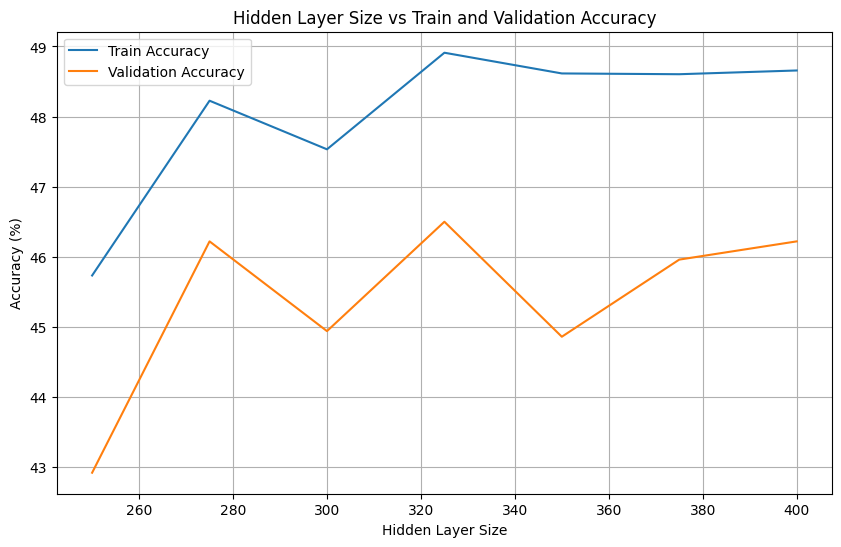

In [ ]:

# We use train_part3 function to train the nn.Sequential 2-layer net      
# for 1 epoch using best optimizer, learning rate, and activation, adjusting 
# the hidden layer sizes.                                                                      

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

hidden_layer_sizes = [250, 275, 300, 325, 350, 375, 400]
best_activation_function = nn.LeakyReLU()
best_optimizer_fn = lambda params: optim.SGD(params, lr=0.004, momentum=0.9)

train_accuracies = []
val_accuracies = []
hidden_layer_results = []

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for hidden_size in hidden_layer_sizes:
    print(f"\nTesting Hidden Layer Size: {hidden_size}")

    model = nn.Sequential(
        nn.Flatten(),
        nn.Linear(3 * 32 * 32, hidden_size),
        best_activation_function,
        nn.Linear(hidden_size, 10),
    )
    model.to(device)

    optimizer = best_optimizer_fn(model.parameters())

    train_part3(model, optimizer, epochs=1, print_every=100)

    train_accuracy = check_accuracy_part3(train_loader, model, device)
    val_accuracy = check_accuracy_part3(val_loader, model, device)

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)
    hidden_layer_results.append({"hidden_size": hidden_size, "train_accuracy": train_accuracy, "val_accuracy": val_accuracy})

    print(f"  Train Accuracy: {train_accuracy:.2f}%")
    print(f"  Validation Accuracy: {val_accuracy:.2f}%")

best_hidden_layer = max(hidden_layer_results, key=lambda x: x["val_accuracy"])

print("\nSummary of Results:")
for result in hidden_layer_results:
    print(f"Hidden Layer Size: {result['hidden_size']}, Train Accuracy: {result['train_accuracy']:.2f}%, Validation Accuracy: {result['val_accuracy']:.2f}%")

print("\nBest Hidden Layer Size:")
print(f"Hidden Layer Size: {best_hidden_layer['hidden_size']}, Train Accuracy: {best_hidden_layer['train_accuracy']:.2f}%, Validation Accuracy: {best_hidden_layer['val_accuracy']:.2f}%")

plt.figure(figsize=(10, 6))
plt.plot(hidden_layer_sizes, train_accuracies, label="Train Accuracy")
plt.plot(hidden_layer_sizes, val_accuracies, label="Validation Accuracy")
plt.xlabel("Hidden Layer Size")
plt.ylabel("Accuracy (%)")
plt.title("Hidden Layer Size vs Train and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()



1.Overfitting Analysis:

If the gap between training and validation accuracy closing, it means the model has trained the training data so well that it isn’t generalizing at all for untested data. In the results:

Training accuracy improves steadily increasing as the hidden layer size increases and the peak is found at the hidden layer size of 325, which gives us 48.91% training data accuracy.

Besides, validation accuracy increases first but is confined within 275 hidden layer size and eventually shows smaller gain. Validation accuracy does not always improve even if the training accuracy doesn’t drop, for hidden layer sizes greater than 350.

For hidden layer sizes greater than 325, this suggests overfitting again, as the training accuracy is high, but the validation accuracy doesn’t increase proportionally.


2.Best Hidden Layer Size:

Validation accuracy is 46.50% and best hidden layer size is 325.

This size allows us to learn the training data while still being able to generalize well to the validation set.
Valid accuracies for smaller hidden layers (250 or 275) do not reach as high of validation accuracy, most likely due to not being able to capture the complexity of the data with enough model capacity.
As we increase hidden layer sizes, for instance 400, the validation accuracy starts to plateau around the setting of 0.86 and the training accuracy continues to climb until around 0.99 indicative of overfitting.

3.Generalization Trade-off:
The trade-off between model capacity and generalization is evident in the results:

Smaller Hidden Layers: If you have a model with too few neurons (say 250), that’d be trying to learn complex data patterns and inside of it, it’ll under fit (both train and validation accuracy will be low).
Larger Hidden Layers: But models with, say, 400 neurons overfit the training data, and pick up noise or irrelevant details, making them hard to generalize from unseen data.
We settle on a hidden layer size of 325 as reasonable for practice use. It turns out it can infer sophisticated patterns given the latest validation accuracy which is the highest. This trade off indicates that it can perform well for very seen and very unseen data, and thus is compatible for real use cases.

## Sequential API: Experiment with Dropout



Overfitting can occur, especially as our model becomes more complex.

Experiment with [Dropout](https://pytorch.org/docs/stable/generated/torch.nn.Dropout.html) to regularize your model:

1.	Add a Dropout layer after the first fully connected layer in your model.

2.	Train the model with the best configuration for 1 epoch with dropout probabilities of `0.1`, `0.3`, `0.5`, `0.7`, `0.9`.

3.	Record the validation accuracy for each dropout probability.

4. Plot a graph showing dropout probability (x-axis) vs. train and validation accuracy (y-axis).


Testing Dropout Probability: 0.1
Iteration 0, loss = 2.3274
Checking accuracy on the val set
Got 381 / 5000 correct (7.62%)

Iteration 100, loss = 1.6170
Checking accuracy on the val set
Got 1931 / 5000 correct (38.62%)

Iteration 200, loss = 1.6464
Checking accuracy on the val set
Got 2099 / 5000 correct (41.98%)

Iteration 300, loss = 1.8308
Checking accuracy on the val set
Got 2194 / 5000 correct (43.88%)

Iteration 400, loss = 1.5206
Checking accuracy on the val set
Got 2186 / 5000 correct (43.72%)

Iteration 500, loss = 1.6649
Checking accuracy on the val set
Got 2153 / 5000 correct (43.06%)

Iteration 600, loss = 1.5099
Checking accuracy on the val set
Got 2301 / 5000 correct (46.02%)

Iteration 700, loss = 1.5535
Checking accuracy on the val set
Got 2264 / 5000 correct (45.28%)

Checking accuracy on the val set
Got 21679 / 45000 correct (48.18%)
Checking accuracy on the val set
Got 2276 / 5000 correct (45.52%)
  Train Accuracy: 48.18%
  Validation Accuracy: 45.52%

Testing Drop

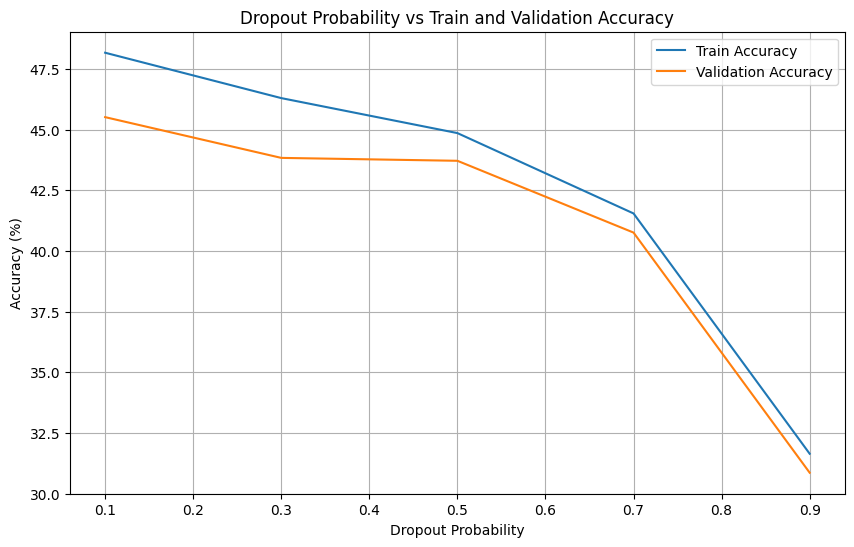

In [ ]:
# We modify the nn.Sequential 2-layer net to include a Dropout layer      
# after the first fully connected layer. Train the model for 1 epoch using   
# the best optimizer, learning rate, and activation, with dropout rates of   
# 0.1, 0.3, 0.5, 0.7, and 0.9. Record validation accuracy for each rate.     

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

hidden_layer_size = 325
dropout_probs = [0.1, 0.3, 0.5, 0.7, 0.9]
best_activation_function = nn.LeakyReLU()
best_optimizer_fn = lambda params: optim.SGD(params, lr=0.004, momentum=0.9)

train_accuracies = []
val_accuracies = []
dropout_results = []

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for dropout_prob in dropout_probs:
    print(f"\nTesting Dropout Probability: {dropout_prob}")

    model = nn.Sequential(
        nn.Flatten(),
        nn.Linear(3 * 32 * 32, hidden_layer_size),
        best_activation_function,
        nn.Dropout(p=dropout_prob),
        nn.Linear(hidden_layer_size, 10),
    )
    model.to(device)

    optimizer = best_optimizer_fn(model.parameters())

    train_part3(model, optimizer, epochs=1, print_every=100)

    train_accuracy = check_accuracy_part3(train_loader, model, device)
    val_accuracy = check_accuracy_part3(val_loader, model, device)

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)
    dropout_results.append({"dropout_prob": dropout_prob, "train_accuracy": train_accuracy, "val_accuracy": val_accuracy})

    print(f"  Train Accuracy: {train_accuracy:.2f}%")
    print(f"  Validation Accuracy: {val_accuracy:.2f}%")



print("\nSummary of Results:")
for result in dropout_results:
    print(f"Dropout Probability: {result['dropout_prob']}, Train Accuracy: {result['train_accuracy']:.2f}%, Validation Accuracy: {result['val_accuracy']:.2f}%")


plt.figure(figsize=(10, 6))
plt.plot(dropout_probs, train_accuracies, label="Train Accuracy")
plt.plot(dropout_probs, val_accuracies, label="Validation Accuracy")
plt.xlabel("Dropout Probability")
plt.ylabel("Accuracy (%)")
plt.title("Dropout Probability vs Train and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()


1.Overfitting Reduction:

In fact, the dropout actually helped in reducing overfitting in the model. I'm assuming overfitting would have made the gap between train and validation accuracy much bigger in the model without dropout.
The train accuracy fell the most (dropped to 46.30% and validation accuracy dropped to 43.84%) at a probability of dropout of 0.3. Finally, it shows that dropout in fact regularised — eliminating overfitting in some measure.

2.Best Dropout Probability:

For this case of learning the dropout probability of 0.1, the validation accuracy yielded was 45.52%, which was one of the highest validation accuracy obtained from this learning.
This value did work well, it was not highly regularized so the model could still learn while somewhat reducing the over fitting. Higher dropout probabilities led to over regularization, resulting in a lower validation accuracy.

3.Too Much Dropout:

At extremely high probability of dropout (0.7, 0.9), the accuracies of both train and validation fell off the cliff. For instance:
At 0.7, train accuracy was 41.55% and validation accuracy was 40.76%.
Validation accuracy gave 30.86%, and train accuracy started dropping at 0.9 to 31.64%.
Regularization means here the features that lead to underfitting provided regularization parameter is too high i.e the model does not gather enough information from the data and doesn't learn the important patterns.

4.Generalization:

With dropout, the network learns more robust features and learns less because it depends less on specific neurons (and the ability to generalize improves). The consideration of model should not over fit to the training data makes model handle unseen dataset better.
In this case however, but a balance between overfitting and learning was found to exist with optimum moderate dropout probability (e.g., 0.1).

Conclusion: 0.1 is the best dropout probability that not only regularizes well but has enough capacity to learn. We reach a highest validation accuracy of 45.52%. This means that because these nebulous dropout probabilities result in underfitting and poor performance, and since this parameter must be tuned correctly, it is.

## Sequential API: Experiment with Learning Rate Schedulers


Learning rate schedulers adjust the learning rate during training and can help the model converge more effectively. By using the best configuration so far (optimizer, learning rate, activation function, and hidden layer size), we will experiment with learning rate schedulers:

- `StepLR`
- `LinearLR`
- `CosineAnnealingLR`
- `ExponentialLR`
- `ReduceLROnPlateau`

1. Refer to the PyTorch [scheduler documentation](https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate) to implement these schedulers.

2.	Train the model for 5 epochs with each scheduler.

3.	We will observe how the validation accuracy evolves over the epochs and determine which scheduler performs best.




Testing Scheduler: StepLR
Epoch 1/5
Iteration 0, loss = 2.3160
Checking accuracy on the val set
Got 688 / 5000 correct (13.76%)

Iteration 100, loss = 1.8858
Checking accuracy on the val set
Got 1968 / 5000 correct (39.36%)

Iteration 200, loss = 1.6128
Checking accuracy on the val set
Got 1988 / 5000 correct (39.76%)

Iteration 300, loss = 1.8484
Checking accuracy on the val set
Got 2159 / 5000 correct (43.18%)

Iteration 400, loss = 1.7830
Checking accuracy on the val set
Got 2154 / 5000 correct (43.08%)

Iteration 500, loss = 1.7754
Checking accuracy on the val set
Got 2254 / 5000 correct (45.08%)

Iteration 600, loss = 1.6156
Checking accuracy on the val set
Got 2278 / 5000 correct (45.56%)

Iteration 700, loss = 1.2237
Checking accuracy on the val set
Got 2304 / 5000 correct (46.08%)

Checking accuracy on the val set
Got 21146 / 45000 correct (46.99%)
Checking accuracy on the val set
Got 2215 / 5000 correct (44.30%)
Epoch 2/5
Iteration 0, loss = 1.7061
Checking accuracy on the va

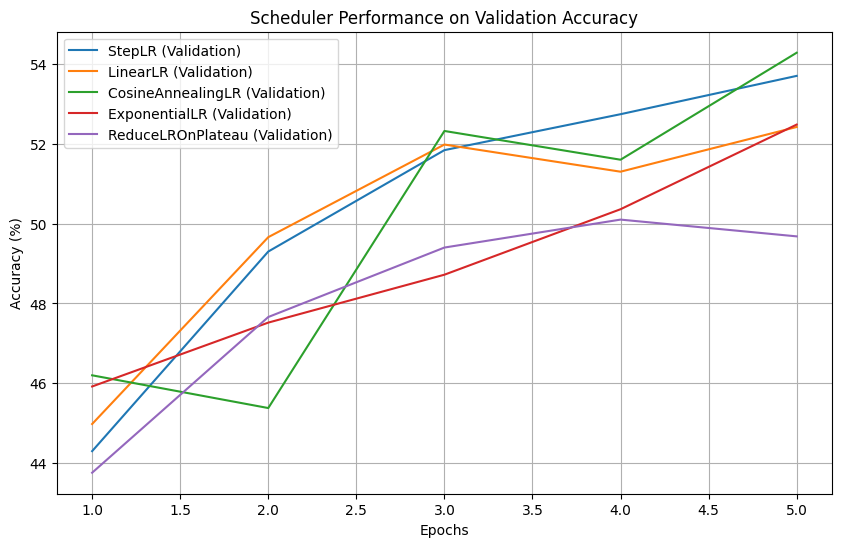


Best Validation Accuracies for Each Scheduler:
StepLR: 53.70%
LinearLR: 52.42%
CosineAnnealingLR: 54.28%
ExponentialLR: 52.48%
ReduceLROnPlateau: 50.10%


In [ ]:

# We will use train_part3 function to train the nn.Sequential 2-layer net      
# for 5 epochs using the best optimizer, learning rate, and activation. Add  
# a learning rate scheduler (`StepLR`, `LinearLR`, etc.).                    
# to the optimizer, and experiment with its impact on validation accuracy.   

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.optim.lr_scheduler import StepLR, LinearLR, CosineAnnealingLR, ExponentialLR, ReduceLROnPlateau

hidden_layer_size = 325
dropout_prob = 0.1
best_activation_function = nn.LeakyReLU()
best_optimizer_fn = lambda params: optim.SGD(params, lr=0.004, momentum=0.9)

schedulers = {
    "StepLR": lambda optimizer: StepLR(optimizer, step_size=1, gamma=0.5),
    "LinearLR": lambda optimizer: LinearLR(optimizer, start_factor=1.0, end_factor=0.2, total_iters=5),
    "CosineAnnealingLR": lambda optimizer: CosineAnnealingLR(optimizer, T_max=5, eta_min=0.0001),
    "ExponentialLR": lambda optimizer: ExponentialLR(optimizer, gamma=0.85),
    "ReduceLROnPlateau": lambda optimizer: ReduceLROnPlateau(optimizer, mode='max', factor=0.7, patience=1),
}

train_accuracies = {name: [] for name in schedulers.keys()}
val_accuracies = {name: [] for name in schedulers.keys()}
best_val_acc = {}  #

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for scheduler_name, scheduler_fn in schedulers.items():
    print(f"\nTesting Scheduler: {scheduler_name}")

    model = nn.Sequential(
        nn.Flatten(),
        nn.Linear(3 * 32 * 32, hidden_layer_size),
        best_activation_function,
        nn.Dropout(p=dropout_prob),
        nn.Linear(hidden_layer_size, 10),
    )
    model.to(device)

    optimizer = best_optimizer_fn(model.parameters())
    scheduler = scheduler_fn(optimizer)

    best_val = 0.0

    for epoch in range(5):
        print(f"Epoch {epoch + 1}/5")
        train_part3(model, optimizer, epochs=1, print_every=100)

        train_accuracy = check_accuracy_part3(train_loader, model, device)
        val_accuracy = check_accuracy_part3(val_loader, model, device)

        train_accuracies[scheduler_name].append(train_accuracy)
        val_accuracies[scheduler_name].append(val_accuracy)

        if val_accuracy > best_val:
            best_val = val_accuracy

        if scheduler_name == "ReduceLROnPlateau":
            scheduler.step(val_accuracy)
        else:
            scheduler.step()

    best_val_acc[scheduler_name] = best_val
    print(f"Scheduler: {scheduler_name} Train Accuracies: {train_accuracies[scheduler_name]}")
    print(f"Scheduler: {scheduler_name} Validation Accuracies: {val_accuracies[scheduler_name]}")
    print(f"Best Validation Accuracy for {scheduler_name}: {best_val:.2f}%")

plt.figure(figsize=(10, 6))
for scheduler_name in schedulers.keys():
    plt.plot(range(1, 6), val_accuracies[scheduler_name], label=f"{scheduler_name} (Validation)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("Scheduler Performance on Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()


print("\nBest Validation Accuracies for Each Scheduler:")
for scheduler_name, val_acc in best_val_acc.items():
    print(f"{scheduler_name}: {val_acc:.2f}%")


## Sequential API: Evaluate the final model on the test set of CIFAR-10



We will be using the best configuration found during the previous experiments (optimizer, learning rate, activation function, hidden layer size, dropout rate, and learning rate scheduler), train the model for 5 epoch and evaluate its performance on the test set.

1.	Report the test accuracy.

2.	Compare it with the validation accuracy to assess if our model generalized well.

In [ ]:

# We will train the nn.Sequential 2-layer net for 5 epochs using the best      
# optimizer, learning rate, activation function, hidden layer size, and      
# dropout rate. Evaluate the trained model on the test set, and compare its  
# performance with validation accuracy.                                      

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR

hidden_layer_size = 325
dropout_prob = 0.1
best_activation_function = nn.LeakyReLU()
best_optimizer_fn = lambda params: optim.SGD(params, lr=0.004, momentum=0.9)
best_scheduler_fn = lambda optimizer: CosineAnnealingLR(optimizer, T_max=5, eta_min=0.0001)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(3 * 32 * 32, hidden_layer_size),
    best_activation_function,
    nn.Dropout(p=dropout_prob),
    nn.Linear(hidden_layer_size, 10),
)
model.to(device)

optimizer = best_optimizer_fn(model.parameters())
scheduler = best_scheduler_fn(optimizer)

print("\nTraining the final model for 5 epochs...")
for epoch in range(5):
    print(f"\nEpoch {epoch + 1}/5")
    train_part3(model, optimizer, epochs=1, print_every=100)
    scheduler.step()

print("\nEvaluating the final model on the test set...")
test_accuracy = check_accuracy_part3(test_loader, model, device)

print(f"\nTest Accuracy: {test_accuracy:.2f}%")


Training the final model for 5 epochs...

Epoch 1/5
Iteration 0, loss = 2.3447
Checking accuracy on the val set
Got 502 / 5000 correct (10.04%)

Iteration 100, loss = 1.8298
Checking accuracy on the val set
Got 1876 / 5000 correct (37.52%)

Iteration 200, loss = 1.6515
Checking accuracy on the val set
Got 2054 / 5000 correct (41.08%)

Iteration 300, loss = 1.5894
Checking accuracy on the val set
Got 2143 / 5000 correct (42.86%)

Iteration 400, loss = 1.8148
Checking accuracy on the val set
Got 2177 / 5000 correct (43.54%)

Iteration 500, loss = 1.6498
Checking accuracy on the val set
Got 2171 / 5000 correct (43.42%)

Iteration 600, loss = 1.7181
Checking accuracy on the val set
Got 2286 / 5000 correct (45.72%)

Iteration 700, loss = 1.6152
Checking accuracy on the val set
Got 2251 / 5000 correct (45.02%)


Epoch 2/5
Iteration 0, loss = 1.6965
Checking accuracy on the val set
Got 2257 / 5000 correct (45.14%)

Iteration 100, loss = 1.3725
Checking accuracy on the val set
Got 2291 / 5000


Baseline accuracy was 34.74%. Regarding the
Optimizers: SGD + momentum worked best, but Adam and AdamW  worked well too.
Activation functions: LeakyReLU, We thought ReLu would be the best as usual but it wasnt this time.
Hidden layer sizes: 250 and 400 we close, but we chose 325 because it had  better accuracy.
Dropout rates: $p = 0.1$ managed to reduce some overfitting without really sacrificing accuracy.
Learning rates: 0.004 worked out to be the best in our case.

The best configuration was:
SGD + momentum, LeakyReLU, 325 hidden layers, 0.1 dropout rate, 0.004 learning rate.

The test accuracy was 0.5391 and valifdation accuracy was 53.91, which suggest very good results (Reletively high accuracy and an excellent ability to generalize).